<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/store_sales_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#https://drive.google.com/drive/folders/1me844NOhTvLMgBq8j9GSKkOFXVOUdDp0?usp=sharing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_holidays_event = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/holidays_events.csv')
df_oil = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/oil.csv')
df_sample_submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/sample_submission.csv')
df_stores = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/stores.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/test.csv')
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/store-sales-time-series-forecasting/train.csv')


# **Dataset Description**

We will going to  predict sales for the thousands of product families sold at Favorita stores located in Ecuador. The training data includes dates, store and product information, whether that item was being promoted, as well as the sales numbers. Additional files include supplementary information that may be useful in building our models.

In [5]:
df_holidays_event.head(50)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [6]:
df_oil.head(2)

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14


In [7]:
df_sample_submission.head(2)

,id,sales
0,3000888,0.0
1,3000889,0.0


In [8]:
df_stores.head(2)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13


In [9]:
df_test.head(2)

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0


In [10]:
df_train.head(2)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0


# **EDA**

In [11]:
df_holidays_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [12]:
df_oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [13]:
df_sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 445.6 KB


In [14]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


Changing the data type

In [17]:
df_holidays_event['date']= pd.to_datetime(df_holidays_event['date'])
df_oil['date']= pd.to_datetime(df_oil['date'])
df_test['date']= pd.to_datetime(df_test['date'])
df_train['date']= pd.to_datetime(df_train['date'])


checking missing values and duplicate values


In [18]:
# Create a list of our dataframes

all_df = [df_holidays_event,df_oil,df_sample_submission,df_stores,df_test,df_train]
names = ["Holidays", "Oil", "Stores", "Transactions", "Test", "Train"]

for i, df_obj in enumerate(all_df):
    print(f"--- Missing Values in {names[i]} ---")
    print(df_obj.isnull().sum())
    print("-" * 30)

--- Missing Values in Holidays ---
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64
------------------------------
--- Missing Values in Oil ---
date           0
dcoilwtico    43
dtype: int64
------------------------------
--- Missing Values in Stores ---
id       0
sales    0
dtype: int64
------------------------------
--- Missing Values in Transactions ---
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64
------------------------------
--- Missing Values in Test ---
id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64
------------------------------
--- Missing Values in Train ---
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
------------------------------


In [19]:
df_oil.head(20)

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


Since oil prices on Saturday are usually the same as Friday, we should use Forward Fill (ffill). This carries the last known value forward until a new one is found.

In [20]:
df_oil['dcoilwtico']= df_oil['dcoilwtico'].ffill().bfill()

In [21]:
df_oil.head(20)

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


In [22]:
from ast import Name
for i, df_obj in enumerate(all_df):
  print(f'---  Duplicate values in {names[i]} --- ')
  print(f'{df_obj.duplicated().sum()}')
  print('--'*30)

---  Duplicate values in Holidays --- 
0
------------------------------------------------------------
---  Duplicate values in Oil --- 
0
------------------------------------------------------------
---  Duplicate values in Stores --- 
0
------------------------------------------------------------
---  Duplicate values in Transactions --- 
0
------------------------------------------------------------
---  Duplicate values in Test --- 
0
------------------------------------------------------------
---  Duplicate values in Train --- 
0
------------------------------------------------------------


<Axes: title={'center': 'Oil Price Trend'}, xlabel='date'>

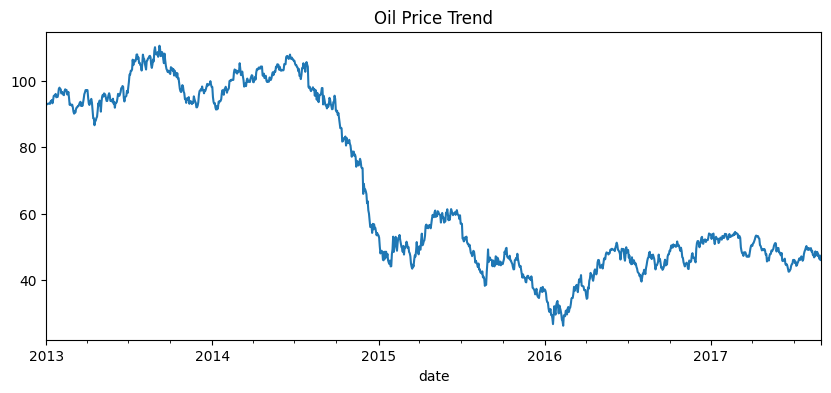

In [23]:
# Let's see the trend of Oil Price
df_oil.set_index('date')['dcoilwtico'].plot(figsize=(10, 4), title="Oil Price Trend")

In [24]:
df_holidays_event['type'].unique()

array(['Holiday', 'Transfer', 'Additional', 'Bridge', 'Work Day', 'Event'],
      dtype=object)

**Holiday**: A standard day off; sales usually drop (stores close) or spike just before it.

**Transfer**: The "new" date a holiday is celebrated; this is the day you will see the actual sales change.

**Bridge**: A "bonus" day off to make a long weekend; usually causes a increase in sales (travel/groceries).

**Additional**: Extra holidays added to major events (like Christmas Eve); these often have the highest sales spikes.

**Work Day**: A "payback" Saturday where people work; sales look like a normal weekday instead of a weekend.

**Event**: External disruptions (like the World Cup or earthquakes); they cause abnormal patterns for several days.

In [25]:
real_holidays = df_holidays_event[(df_holidays_event['transferred']==False) & (df_holidays_event['type']!= 'Work Day')]
real_holidays.shape

(333, 6)

In [26]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [27]:
df_train['sales'].describe()

,sales
count,3.000888e+06
mean,3.577757e+02
std,1.101998e+03
min,0.000000e+00
25%,0.000000e+00
50%,1.100000e+01
75%,1.958473e+02
max,1.247170e+05


In [28]:
df_train.sort_values(by = 'date', inplace = True)
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1194,1194,2013-01-01,42,CELEBRATION,0.0,0
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0
1192,1192,2013-01-01,42,BOOKS,0.0,0
1191,1191,2013-01-01,42,BEVERAGES,0.0,0


In [29]:
df_train.reset_index(drop = True,inplace= True)

In [30]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1194,2013-01-01,42,CELEBRATION,0.0,0
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0
3,1192,2013-01-01,42,BOOKS,0.0,0
4,1191,2013-01-01,42,BEVERAGES,0.0,0


To study monthly sales, we need to group the rows of df by month and sum up the values in each group. We will use the Grouper function in conjunction with the groupby operation for grouping. Grouper is a function in the pandas library that allow us to group time series data based on a specific frequency (freq) which in our case is monthly (M).

In [31]:
per_day_sales = df_train.groupby(pd.Grouper(key='date', freq = 'D'))['sales'].sum()
Monthly_sales = df_train.groupby(pd.Grouper(key='date', freq = 'M'))['sales'].sum()
Yearly_sales = df_train.groupby(pd.Grouper( key= 'date', freq = 'Y'))['sales'].sum()

/tmp/ipykernel_24683/321923259.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Monthly_sales = df_train.groupby(pd.Grouper(key='date', freq = 'M'))['sales'].sum()
/tmp/ipykernel_24683/321923259.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  Yearly_sales = df_train.groupby(pd.Grouper( key= 'date', freq = 'Y'))['sales'].sum()


In [32]:
real_holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [33]:
per_day_sales

,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229
...,...
2017-08-11,826373.722022
2017-08-12,792630.535079
2017-08-13,865639.677471


In [34]:
daily_sales = per_day_sales.reset_index()
daily_sales['Is_holiday']= daily_sales['date'].isin(real_holidays['date'])
daily_sales

,date,sales,Is_holiday
0,2013-01-01,2511.618999,True
1,2013-01-02,496092.417944,False
2,2013-01-03,361461.231124,False
3,2013-01-04,354459.677093,False
4,2013-01-05,477350.121229,False
...,...,...,...
1683,2017-08-11,826373.722022,True
1684,2017-08-12,792630.535079,False
1685,2017-08-13,865639.677471,False
1686,2017-08-14,760922.406081,False


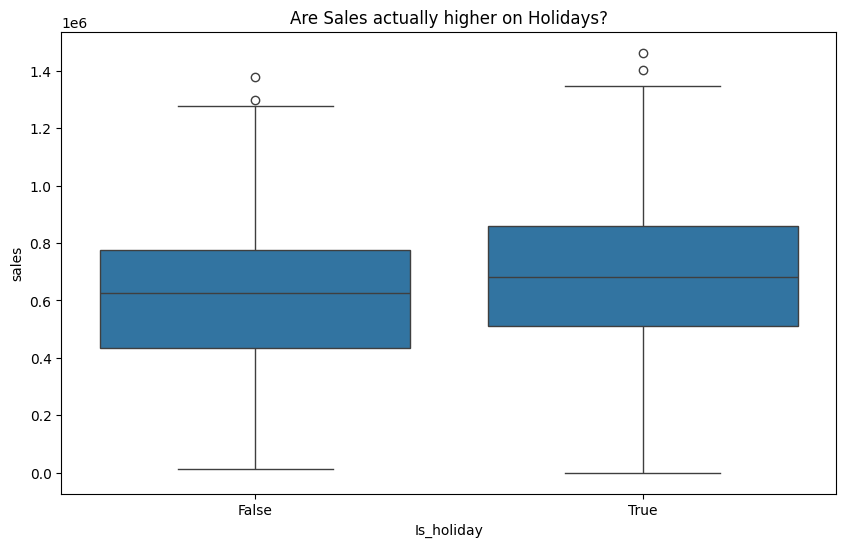

In [35]:
# Compare average sales: Holiday vs. Normal Day
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_sales, x='Is_holiday', y='sales')
plt.title('Are Sales actually higher on Holidays?')
plt.show()

In [36]:
holiday_filter = daily_sales[daily_sales['Is_holiday'] == True]

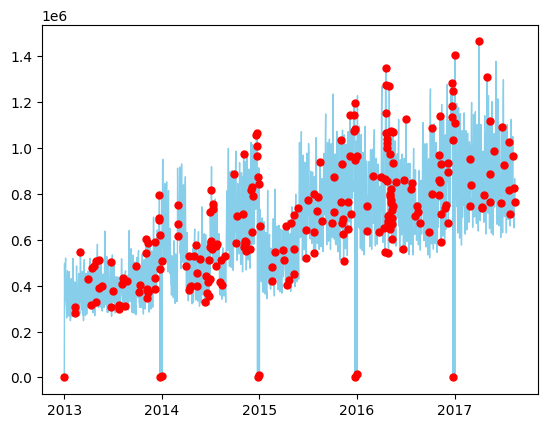

In [38]:
plt.plot(per_day_sales.index, per_day_sales.values, label='Daily Sales', color='skyblue', linewidth=1)
plt.scatter(holiday_filter['date'], holiday_filter['sales'], color='red', s=25, label='Holiday Points', zorder=5)